# PM 사고 위험구역 예측 — 파일럿 연구

**2026 KT 디지털인재장학생 · AI기반 사회문제해결 프로젝트 / 대전·충청 팀**

> 실시간 교통 상황(날씨·시간대·이동량)을 반영하는 PM 사고 위험구역 예측 — 본 데이터(KT·한국교통안전공단) 확보 **이전**, 지금 접근 가능한 데이터만으로 *예측 타당성*을 검증하고 *무엇을 요청해야 하는지*를 정량 근거와 함께 도출하는 파일럿.

## 0. 연구 설계

**최종 제품과의 관계** — 본 서비스는 ① GPS로 시간대별 위험구역을 탐지하고 ② 보행자가 위험구역에 진입하면 BLE로 주변 PM 디바이스를 감지해 ③ 가까워지면 이어폰으로 경고한다. 이 중 **①의 핵심인 "위험구역 예측 모델"의 데이터 요구사항**을 본 파일럿에서 규명한다.

**연구 질문**
1. 지금 접근 가능한 데이터(도로 구조·시간대·날씨)만으로 위험구역을 얼마나 예측할 수 있는가?
2. 어떤 피처가 위험을 설명하는가? (→ 어떤 데이터를 요청해야 하는가)
3. KT 이동량/체류인구·공단 주행궤적 데이터를 추가하면 예측이 얼마나 개선되는가? (→ 요청의 정량적 정당화)

**데이터 정직성 (반드시 읽을 것)**

| 데이터 | 본 노트북에서의 출처 | 비고 |
|---|---|---|
| 대전 도로망·교차로·상권(POI) | **실제** — OSM을 osmnx로 실시간 수집 | 진짜 대전 공간 구조 |
| 대학 위치 | **실제** — KAIST·충남대·한밭대·배재대·우송대 좌표 | |
| PM 사고 이력 | **합성(보정)** — `data/`에 실 CSV가 있으면 자동 대체 | data.go.kr 직접 수집이 anti-bot으로 차단됨 |
| 기상(시간별) | **합성(보정)** — 실 CSV 있으면 대체 | data.kma.go.kr 로그인 필요 |

> 사고 데이터는 PROJECT.html·문헌의 **실제 통계**(시간대 저녁 피크, 연 2.5배 증가, 대학가·상권 핫스팟, 핫스팟 도로 2.7%)로 보정한 생성 모델로 만든다. 생성 과정에서 **잠재 노출량 `lat_expo` = (OSM으로 관측 가능한 구조 성분) + (OSM에 없는 독립 성분 = 실제 PM 통행수요)** 로 설계한다. 즉 도로·상권 구조는 노출을 *부분적으로만* 대리하고, 진짜 PM 이동량은 KT·공단 데이터에만 있다. 따라서 ablation에서 노출 참값을 추가했을 때의 성능 향상폭이 곧 **"KT 이동량·공단 주행궤적 데이터가 채울 정보의 가치"**를 시뮬레이션으로 정량화한 값이 된다.
>
> **결론의 성격** — 구체적 *계수*는 실데이터 확보 후 확정되지만, *방법론의 작동 여부*와 *데이터 카테고리별 상대적 가치*에 대한 결론은 본 파일럿으로 도출 가능하다.

## 1. 환경 설정

In [1]:
import os, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# 한글 폰트 (Windows: Malgun Gothic)
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _c in ["Malgun Gothic", "NanumGothic", "Batang", "Gulim"]:
    if _c in _avail:
        mpl.rcParams["font.family"] = _c
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110

SEED = 42
RNG = np.random.default_rng(SEED)

DATA = Path("data"); DATA.mkdir(exist_ok=True)
CACHE = DATA / "cache"; CACHE.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print("matplotlib font :", mpl.rcParams["font.family"])
print("data dir        :", DATA.resolve())

matplotlib font : ['Malgun Gothic']
data dir        : C:\Users\BREW\Downloads\AI기반사회문제해결프로젝트\proj\data


## 2. 데이터 획득 레이어

각 소스는 `data/`에 실 파일이 있으면 그것을, 없으면 보정 합성 데이터를 사용한다.
아래는 실데이터로 교체하기 위한 다운로드 안내다.

In [2]:
SOURCES = {
    "accidents": {
        "file": DATA / "daejeon_pm_accidents.csv",
        "title": "대전 PM 교통사고 이력",
        "how": [
            "공공데이터포털 data.go.kr/data/15123495 (경찰청 대전 PM 법규위반별 교통사고, 로그인 불필요)",
            "또는 TAAS taas.koroad.or.kr > 통계 > 수단별 > 개인형이동장치 > 대전 필터 > 다운로드",
        ],
        "schema": "필요 컬럼: date(YYYY-MM-DD), hour(0-23), lat, lon, severity[경상/중상/사망]  (lat/lon 없으면 구/동 단위도 허용)",
    },
    "weather": {
        "file": DATA / "daejeon_weather_hourly.csv",
        "title": "대전 시간별 기상 (ASOS)",
        "how": [
            "기상자료개방포털 data.kma.go.kr > 지상관측 > 종관기상(ASOS) > 대전(지점 133) > 시간자료 CSV",
        ],
        "schema": "필요 컬럼: datetime, temp(℃), precip(mm), humidity(%), wind(m/s)",
    },
}

def describe_sources():
    rows = []
    for k, s in SOURCES.items():
        rows.append({
            "key": k, "데이터": s["title"],
            "상태": "실데이터 ✅" if s["file"].exists() else "합성(보정) ⚠",
            "경로": str(s["file"].name),
        })
    return pd.DataFrame(rows)

print("=== 실데이터 교체 안내 ===")
for k, s in SOURCES.items():
    print(f"\n[{k}] {s['title']}  ->  {s['file']}")
    for h in s["how"]:
        print("   -", h)
    print("   schema:", s["schema"])
describe_sources()

=== 실데이터 교체 안내 ===

[accidents] 대전 PM 교통사고 이력  ->  data\daejeon_pm_accidents.csv
   - 공공데이터포털 data.go.kr/data/15123495 (경찰청 대전 PM 법규위반별 교통사고, 로그인 불필요)
   - 또는 TAAS taas.koroad.or.kr > 통계 > 수단별 > 개인형이동장치 > 대전 필터 > 다운로드
   schema: 필요 컬럼: date(YYYY-MM-DD), hour(0-23), lat, lon, severity[경상/중상/사망]  (lat/lon 없으면 구/동 단위도 허용)

[weather] 대전 시간별 기상 (ASOS)  ->  data\daejeon_weather_hourly.csv
   - 기상자료개방포털 data.kma.go.kr > 지상관측 > 종관기상(ASOS) > 대전(지점 133) > 시간자료 CSV
   schema: 필요 컬럼: datetime, temp(℃), precip(mm), humidity(%), wind(m/s)


,key,데이터,상태,경로
0,accidents,대전 PM 교통사고 이력,합성(보정) ⚠,daejeon_pm_accidents.csv
1,weather,대전 시간별 기상 (ASOS),합성(보정) ⚠,daejeon_weather_hourly.csv


## 3. 실제 대전 도로망·POI 수집 (OSM) + 격자 생성

대전 중심부(유성 대학가·서구 둔산·중구 일대)를 500 m 격자로 나누고, 각 셀의 **실제** 도로 길이·간선도로·교차로·상권(POI) 밀도를 계산한다. 결과는 캐시되어 재실행 시 즉시 로드된다.

In [3]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box, Point

ox.settings.use_cache = True
ox.settings.cache_folder = str(CACHE / "osmnx")

# 대전 중심부 bbox (W,S,E,N) — 충남대/KAIST/한밭대/배재대/우송대/둔산 포함
WEST, SOUTH, EAST, NORTH = 127.30, 36.31, 127.43, 36.39
PROJ = "EPSG:32652"   # UTM 52N (meter)
CELL_M = 500.0

graph_path = CACHE / "daejeon_drive.graphml"
OSM_OK = True
try:
    if graph_path.exists():
        G = ox.load_graphml(graph_path); src = "cache"
    else:
        G = ox.graph_from_bbox((WEST, SOUTH, EAST, NORTH), network_type="drive")
        ox.save_graphml(G, graph_path); src = "OSM live"
    nodes, edges = ox.graph_to_gdfs(G)
    print(f"[OSM:{src}] nodes={len(nodes)}  edges={len(edges)}")
except Exception as e:
    OSM_OK = False
    print("OSM 수집 실패 → 합성 격자 피처 사용:", repr(e)[:160])

[OSM:cache] nodes=7883  edges=22264


In [4]:
# 500m 격자 (투영 좌표계)
bbox_proj = gpd.GeoDataFrame(geometry=[box(WEST, SOUTH, EAST, NORTH)],
                             crs="EPSG:4326").to_crs(PROJ)
minx, miny, maxx, maxy = bbox_proj.total_bounds
xs = np.arange(minx, maxx, CELL_M)
ys = np.arange(miny, maxy, CELL_M)
recs = []
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        recs.append({"cell_id": f"{i:02d}_{j:02d}", "ix": i, "iy": j,
                     "geometry": box(x, y, x + CELL_M, y + CELL_M)})
grid = gpd.GeoDataFrame(recs, crs=PROJ)
cent = grid.geometry.centroid
grid["cx"], grid["cy"] = cent.x, cent.y
cll = gpd.GeoDataFrame(geometry=cent, crs=PROJ).to_crs("EPSG:4326")
grid["lon"], grid["lat"] = cll.geometry.x.values, cll.geometry.y.values
print("격자 셀 수:", len(grid))

격자 셀 수: 456


In [5]:
# 셀별 도로 피처 (실 OSM)
ARTERIAL = {"primary","secondary","trunk","primary_link","secondary_link","trunk_link","tertiary"}
def _is_art(h):
    h = h[0] if isinstance(h, list) else h
    return h in ARTERIAL

if OSM_OK:
    ep = edges.to_crs(PROJ).reset_index()
    ep["seg_len"] = ep.geometry.length
    ep["arterial"] = ep["highway"].apply(_is_art)
    je = gpd.sjoin(ep[["seg_len","arterial","geometry"]],
                   grid[["cell_id","geometry"]], how="inner", predicate="intersects")
    road = je.groupby("cell_id").agg(road_len=("seg_len","sum"),
                                     n_edges=("seg_len","size")).reset_index()
    art = (je[je["arterial"]].groupby("cell_id")["seg_len"].sum()
           .rename("arterial_len").reset_index())
    road = road.merge(art, on="cell_id", how="left")

    npr = nodes.to_crs(PROJ).reset_index()
    if "street_count" not in npr.columns:
        npr["street_count"] = 3
    inter = npr[npr["street_count"] >= 3]
    ji = gpd.sjoin(inter[["street_count","geometry"]],
                   grid[["cell_id","geometry"]], how="inner", predicate="within")
    icnt = ji.groupby("cell_id").size().rename("n_intersections").reset_index()
    grid = grid.merge(road, on="cell_id", how="left").merge(icnt, on="cell_id", how="left")
else:
    n = len(grid)
    grid["road_len"] = RNG.gamma(2, 1500, n)
    grid["arterial_len"] = grid["road_len"] * RNG.uniform(0, 0.4, n)
    grid["n_edges"] = RNG.poisson(20, n)
    grid["n_intersections"] = RNG.poisson(8, n)

for c in ["road_len","arterial_len","n_edges","n_intersections"]:
    grid[c] = grid[c].fillna(0.0)
grid["intersection_density"] = grid["n_intersections"] / (CELL_M*CELL_M/1e6)  # /km^2
grid[["cell_id","road_len","arterial_len","n_intersections","intersection_density"]].describe().round(1)

,road_len,arterial_len,n_intersections,intersection_density
count,456.0,456.0,456.0,456.0
mean,6696.9,2295.1,16.5,66.1
std,4815.0,2012.9,17.1,68.3
min,0.0,0.0,0.0,0.0
25%,2837.2,359.2,2.0,8.0
50%,6219.9,2127.5,10.0,40.0
75%,10125.6,3473.6,28.0,112.0
max,19244.4,9615.1,75.0,300.0


In [6]:
# 셀별 상권/시설 POI 밀도 (실 OSM) + 대학까지 거리 (실 좌표)
try:
    tags = {"amenity": ["restaurant","cafe","bar","pub","fast_food",
                         "university","college","school"]}
    poi = ox.features_from_bbox((WEST, SOUTH, EAST, NORTH), tags)
    poi = poi[poi.geometry.notna()].to_crs(PROJ)
    poi["geometry"] = poi.geometry.centroid
    jp = gpd.sjoin(poi[["geometry"]], grid[["cell_id","geometry"]],
                   how="inner", predicate="within")
    pc = jp.groupby("cell_id").size().rename("n_poi").reset_index()
    grid = grid.merge(pc, on="cell_id", how="left")
    print("수집 POI 수:", len(poi))
except Exception as e:
    print("POI 수집 실패 → 0 처리:", repr(e)[:120]); grid["n_poi"] = 0.0
grid["n_poi"] = grid["n_poi"].fillna(0.0)

UNIV = {"KAIST":(36.3741,127.3604), "충남대":(36.3664,127.3447),
        "한밭대":(36.3509,127.3015), "배재대":(36.3215,127.3565),
        "우송대":(36.3360,127.4283)}
uni = gpd.GeoDataFrame(geometry=[Point(lo, la) for la, lo in UNIV.values()],
                       crs="EPSG:4326").to_crs(PROJ)
cc = gpd.GeoDataFrame(geometry=gpd.points_from_xy(grid["cx"].values, grid["cy"].values), crs=PROJ)
grid["dist_univ"] = cc.geometry.apply(lambda g: float(uni.distance(g).min()))
print("대학 최단거리(m):", grid["dist_univ"].min().round(0), "~", grid["dist_univ"].max().round(0))
grid[["cell_id","n_poi","dist_univ"]].head()

수집 POI 수: 668
대학 최단거리(m): 40.0 ~ 6366.0


,cell_id,n_poi,dist_univ
0,00_00,0.0,4482.318766
1,00_01,0.0,3982.336529
2,00_02,0.0,3482.359392
3,00_03,0.0,2982.389921
4,00_04,0.0,2482.432748


## 4. 사고·기상 데이터 (실 CSV 자동 사용 / 없으면 보정 합성)

생성 모델은 **잠재 노출량 `lat_expo` = 구조 성분(도로·교차로·상권·대학 근접) + 독립 성분(실제 PM 통행수요)**을 ground truth로 두고, 시간대(저녁 피크)·요일(주말↑)·강수(↑)·연도(2019→2023 증가) 승수를 곱해 셀×시간대×요일×강수 패널의 사고 기대값을 만든 뒤 포아송 추출한다. OSM 피처는 구조 성분만 복원할 수 있어 독립 성분(PM 실수요)을 놓친다. 따라서 ablation에서 노출 참값을 넣으면 "완전한 노출 데이터(=KT 이동량·공단 주행궤적)"의 가치가 드러난다.

In [7]:
def _z(s):
    s = np.asarray(s, float)
    return (s - s.mean()) / (s.std() + 1e-9)

# 잠재 노출량(ground truth) = 관측가능 구조 성분 + 관측불가 PM 실수요 성분
g = grid.reset_index(drop=True).copy()
# (1) OSM으로 관측 가능한 구조 성분 — 모델이 대리변수로 복원 가능
struct = (0.9*_z(np.log1p(g["road_len"])) +
          1.0*_z(g["n_intersections"]) +
          1.2*_z(np.log1p(g["n_poi"])) +
          1.1*_z(np.exp(-g["dist_univ"]/1200.0)))
# (2) OSM에 없는 독립 성분 = 실제 PM 통행수요(이동량/체류인구) → KT·공단 데이터가 채울 정보
hidden_demand = RNG.normal(0, 1, len(g))
grid["hidden_demand"] = hidden_demand
lat_expo = 0.85*_z(struct) + 0.55*_z(hidden_demand)   # 구조 ~70% + PM 실수요 ~30%
grid["lat_expo"] = lat_expo
grid["struct_score"] = _z(struct)
base = np.exp(1.0*lat_expo)           # 셀 기본 강도(상대값) — 총량은 TARGET으로 보정

# 시간대(7구간)·주말·강수 패널 (벡터화 cross join)
dayparts = [("심야",0,6,0.30), ("아침",6,9,0.75), ("오전",9,12,0.60),
            ("오후",12,15,0.85), ("초저녁",15,18,1.05), ("저녁",18,21,1.65),
            ("밤",21,24,0.90)]
dp_df = pd.DataFrame(dayparts, columns=["daypart","h0","h1","dp_mult"])
dp_df["hours"] = dp_df["h1"] - dp_df["h0"]
wk_df = pd.DataFrame({"weekend":[0,1], "wk_mult":[1.0,1.2], "wk_prev":[5/7,2/7]})
rn_df = pd.DataFrame({"rain":[0,1], "rn_mult":[1.0,1.45], "rn_prev":[0.88,0.12]})

gg = grid[["cell_id"]].copy(); gg["base"] = np.asarray(base)
for d in (gg, dp_df, wk_df, rn_df): d["_k"] = 1
TARGET_ACC = 4000   # 전체 사고 규모(셀당 평균을 충분히 확보해 희소성 노이즈 억제)
panel = (gg.merge(dp_df, on="_k").merge(wk_df, on="_k").merge(rn_df, on="_k")
         .drop(columns="_k"))
mean_raw = (panel.base*panel.dp_mult*panel.wk_mult*panel.rn_mult
            *panel.hours*panel.wk_prev*panel.rn_prev)
panel["mean"] = mean_raw * (TARGET_ACC / mean_raw.sum())   # 기대 총량 = TARGET_ACC
panel["cnt"] = RNG.poisson(panel["mean"].values)
print(f"패널 행수={len(panel)}  생성 사고 총건수={int(panel.cnt.sum())}  셀당평균={panel.groupby('cell_id').cnt.sum().mean():.1f}")

패널 행수=12768  생성 사고 총건수=3957  셀당평균=8.7


In [8]:
# 패널 → 개별 사고 이벤트 확장 (EDA·지도용). 실 CSV 있으면 그것을 사용.
def synth_events():
    idx = np.repeat(panel.index.values, panel["cnt"].values)
    e = panel.loc[idx, ["cell_id","h0","h1","weekend","rain","daypart"]].reset_index(drop=True)
    m = len(e)
    span = (e["h1"] - e["h0"]).values
    e["hour"] = (e["h0"].values + (RNG.random(m) * span)).astype(int)
    e["dow"] = np.where(e["weekend"] == 1, RNG.integers(5, 7, m), RNG.integers(0, 5, m))
    yw = np.array([1.0, 1.2, 1.5, 1.9, 2.3]); yw = yw / yw.sum()
    e["year"] = RNG.choice([2019, 2020, 2021, 2022, 2023], m, p=yw)
    e["month"] = RNG.integers(1, 13, m)
    e["temp"] = 13 + 12*np.sin((e["month"]-4)/12*2*np.pi) + RNG.normal(0, 3, m)
    e["severity"] = RNG.choice(["경상","중상","사망"], m, p=[0.80, 0.18, 0.02])
    e = e.merge(grid[["cell_id","lat","lon"]], on="cell_id")
    e["lat"] = e["lat"] + RNG.normal(0, 0.0015, m)
    e["lon"] = e["lon"] + RNG.normal(0, 0.0018, m)
    return e

if SOURCES["accidents"]["file"].exists():
    events = pd.read_csv(SOURCES["accidents"]["file"])
    print("실 사고 데이터 로드:", events.shape, "(컬럼 매핑 필요 시 수정)")
    DATA_MODE = "real"
else:
    events = synth_events()
    DATA_MODE = "synthetic"
    print("⚠ 합성 사고 데이터 사용 — 건수:", len(events))
events.head()

⚠ 합성 사고 데이터 사용 — 건수: 3957


,cell_id,h0,h1,weekend,rain,daypart,hour,dow,year,month,temp,severity,lat,lon
0,00_01,21,24,0,0,밤,21,0,2023,2,1.403295,경상,36.315422,127.301725
1,00_02,9,12,0,0,오전,10,4,2020,4,13.000667,경상,36.320301,127.305398
2,00_02,9,12,1,0,오전,10,5,2020,3,9.698478,경상,36.321453,127.301439
3,00_03,0,6,0,0,심야,3,3,2022,12,2.013071,경상,36.325492,127.301042
4,00_03,9,12,0,0,오전,11,1,2019,7,34.331776,경상,36.324803,127.302386


## 5. 탐색적 시각화 (EDA)

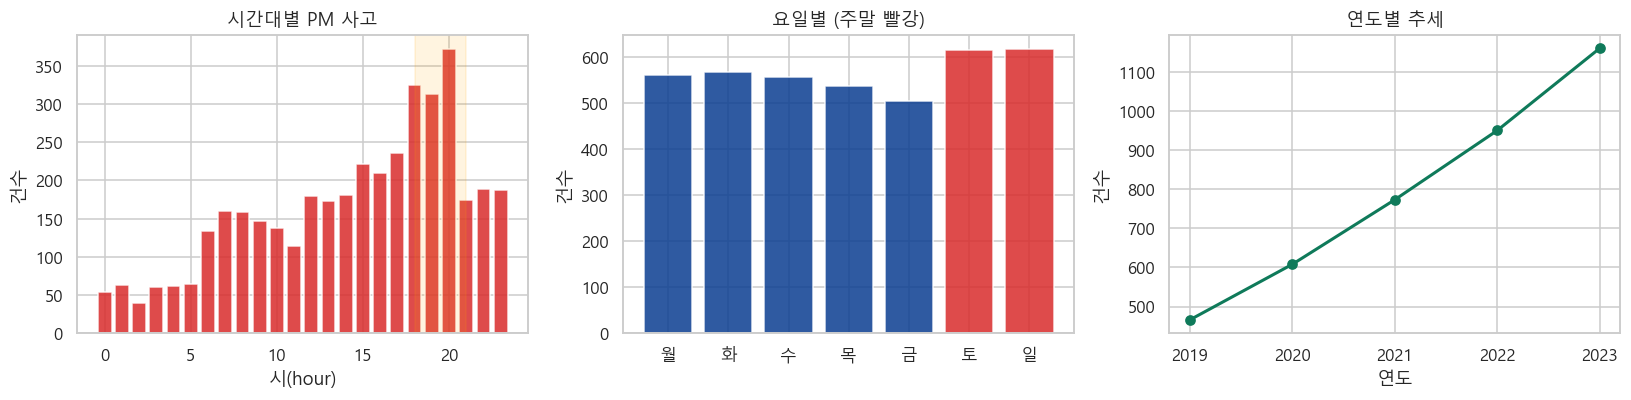

In [9]:
# 5-1. 시간 패턴: 시간대 / 요일 / 연도
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
hourly = events.groupby("hour").size()
ax[0].bar(hourly.index, hourly.values, color="#D92B2B", alpha=0.85)
ax[0].set_title("시간대별 PM 사고"); ax[0].set_xlabel("시(hour)"); ax[0].set_ylabel("건수")
ax[0].axvspan(18, 21, color="orange", alpha=0.12)

dow_lab = ["월","화","수","목","금","토","일"]
dow = events.groupby("dow").size().reindex(range(7), fill_value=0)
cols = ["#0A3D91"]*5 + ["#D92B2B"]*2
ax[1].bar(dow_lab, dow.values, color=cols, alpha=0.85)
ax[1].set_title("요일별 (주말 빨강)"); ax[1].set_ylabel("건수")

yr = events.groupby("year").size()
ax[2].plot(yr.index, yr.values, "-o", color="#0F7A5A", lw=2)
ax[2].set_title("연도별 추세"); ax[2].set_xlabel("연도"); ax[2].set_ylabel("건수")
plt.tight_layout(); plt.show()

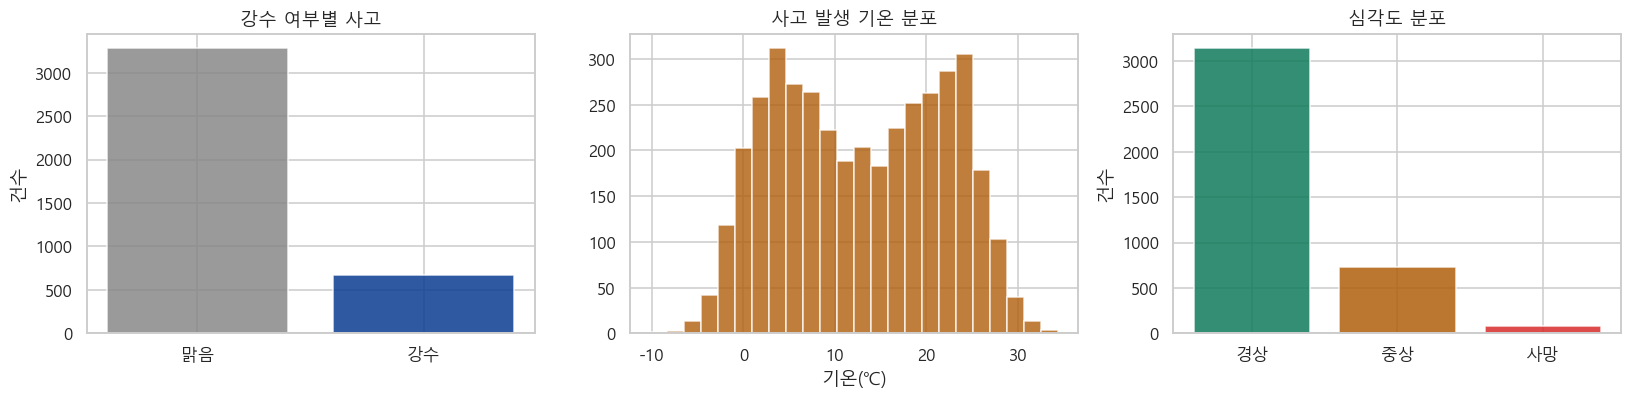

In [10]:
# 5-2. 날씨·심각도
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
rain_cnt = events.groupby("rain").size().reindex([0,1], fill_value=0)
ax[0].bar(["맑음","강수"], rain_cnt.values, color=["#888","#0A3D91"], alpha=0.85)
ax[0].set_title("강수 여부별 사고"); ax[0].set_ylabel("건수")

ax[1].hist(events["temp"], bins=24, color="#B05E0A", alpha=0.8)
ax[1].set_title("사고 발생 기온 분포"); ax[1].set_xlabel("기온(℃)")

sev = events["severity"].value_counts().reindex(["경상","중상","사망"]).fillna(0)
ax[2].bar(sev.index, sev.values, color=["#0F7A5A","#B05E0A","#D92B2B"], alpha=0.85)
ax[2].set_title("심각도 분포"); ax[2].set_ylabel("건수")
plt.tight_layout(); plt.show()

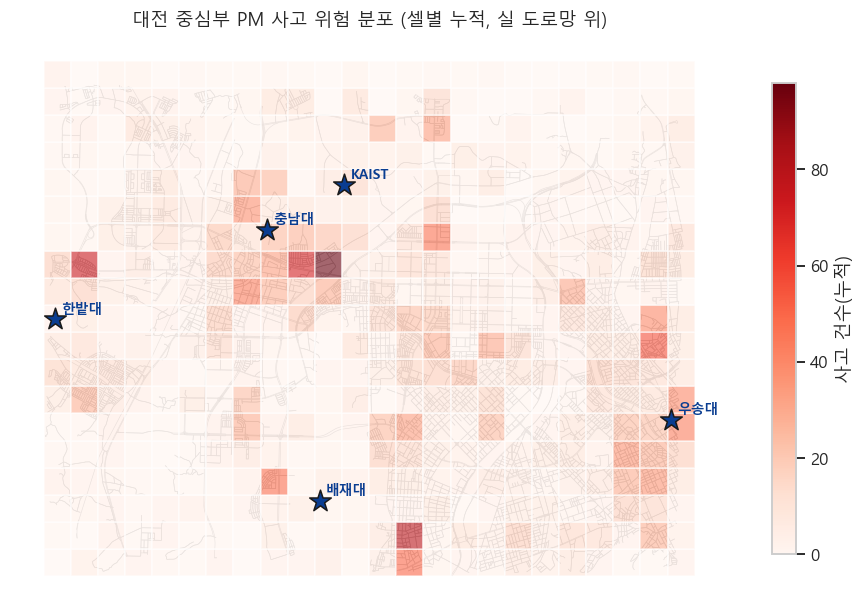

In [11]:
# 5-3. 공간 분포 — 셀별 사고 합계 choropleth + 도로망 overlay (실 OSM)
cell_acc = panel.groupby("cell_id")["cnt"].sum().rename("acc")
gmap = grid.merge(cell_acc, on="cell_id", how="left")
gmap["acc"] = gmap["acc"].fillna(0)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
if OSM_OK:
    edges.to_crs(PROJ).plot(ax=ax, color="#cccccc", lw=0.4, zorder=1)
gmap.plot(column="acc", cmap="Reds", alpha=0.6, ax=ax, zorder=2,
          legend=True, legend_kwds={"label": "사고 건수(누적)", "shrink": 0.6})
# 대학 표시
up = uni.copy()
ax.scatter(up.geometry.x, up.geometry.y, marker="*", s=220,
           edgecolor="k", facecolor="#0A3D91", zorder=4)
for name, (la, lo) in UNIV.items():
    p = gpd.GeoSeries([Point(lo, la)], crs="EPSG:4326").to_crs(PROJ).iloc[0]
    ax.annotate(name, (p.x, p.y), fontsize=9, fontweight="bold",
                color="#0A3D91", xytext=(4, 4), textcoords="offset points", zorder=5)
ax.set_title("대전 중심부 PM 사고 위험 분포 (셀별 누적, 실 도로망 위)")
ax.set_axis_off(); plt.tight_layout(); plt.show()

In [12]:
# 5-4. 인터랙티브 지도 (folium) — 상위 위험 셀
import folium
m = folium.Map(location=[(SOUTH+NORTH)/2, (WEST+EAST)/2], zoom_start=12,
               tiles="cartodbpositron")
gm4326 = gmap.to_crs("EPSG:4326")
vmax = max(gmap["acc"].max(), 1)
for _, r in gm4326.iterrows():
    if r["acc"] <= 0:
        continue
    inten = r["acc"]/vmax
    folium.GeoJson(r["geometry"].__geo_interface__,
        style_function=lambda x, c=inten: {
            "fillColor": "#D92B2B", "color": "#D92B2B",
            "weight": 0.3, "fillOpacity": 0.15 + 0.6*c}).add_to(m)
for name, (la, lo) in UNIV.items():
    folium.Marker([la, lo], tooltip=name,
                  icon=folium.Icon(color="blue", icon="graduation-cap", prefix="fa")).add_to(m)
m.save(str(DATA / "risk_map.html"))
print("저장: data/risk_map.html")
m

저장: data/risk_map.html


## 6. 상관 분석

셀 단위 피처와 사고 건수의 상관을 본다. **현재 접근 가능한 피처는 모두 노출의 *대리변수***(도로·상권·대학 근접)일 뿐, 실제 *통행량/체류인구*는 직접 측정하지 못한다 — 이 **노출 갭**이 본 파일럿의 핵심 발견이다.

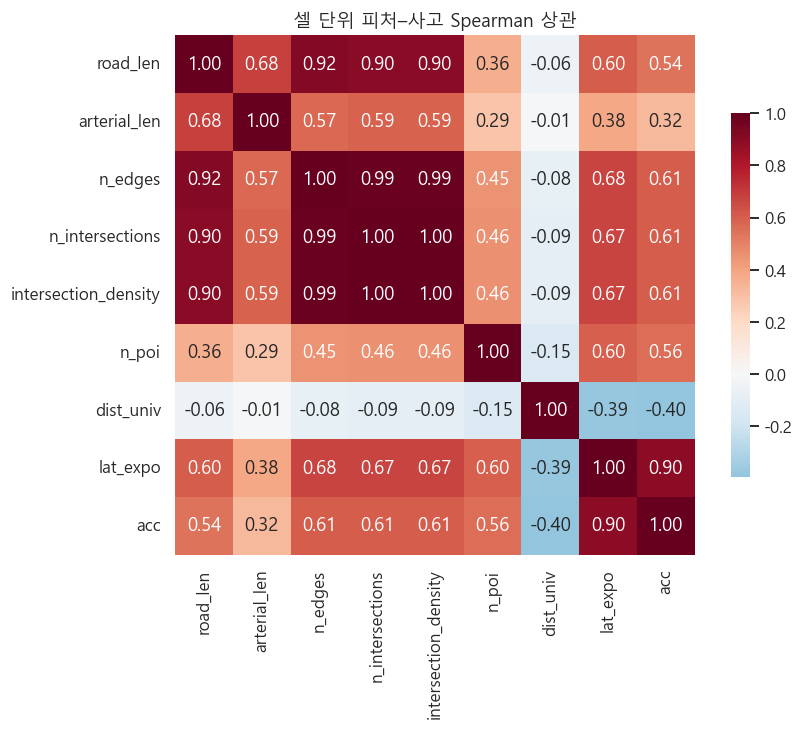

사고(acc)와의 상관 (절댓값 내림차순):
lat_expo                0.896
n_intersections         0.607
intersection_density    0.607
n_edges                 0.605
n_poi                   0.562
road_len                0.542
dist_univ              -0.395
arterial_len            0.321
Name: acc, dtype: float64


In [13]:
feat_struct = ["road_len","arterial_len","n_edges","n_intersections",
               "intersection_density","n_poi","dist_univ"]
corr_df = grid.merge(cell_acc, on="cell_id", how="left").fillna({"acc":0})
corr_cols = feat_struct + ["lat_expo","acc"]
C = corr_df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 6.8))
sns.heatmap(C, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink":0.7}, ax=ax)
ax.set_title("셀 단위 피처–사고 Spearman 상관")
plt.tight_layout(); plt.show()

print("사고(acc)와의 상관 (절댓값 내림차순):")
print(C["acc"].drop("acc").reindex(C["acc"].drop("acc").abs().sort_values(ascending=False).index).round(3))

In [14]:
# 노출 갭 시각화: lat_expo(참 노출) 대비 개별 OSM 대리변수의 설명력
from scipy.stats import spearmanr
proxies = ["road_len","n_intersections","n_poi","dist_univ"]
rows = []
for p in proxies:
    rho_acc, _ = spearmanr(corr_df[p], corr_df["acc"])
    rho_exp, _ = spearmanr(corr_df[p], corr_df["lat_expo"])
    rows.append({"대리변수": p, "vs 사고(ρ)": round(rho_acc,3),
                 "vs 참노출(ρ)": round(rho_exp,3)})
gap = pd.DataFrame(rows)
rho_full, _ = spearmanr(corr_df["lat_expo"], corr_df["acc"])
print(f"참 노출(lat_expo) ↔ 사고 상관 = {rho_full:.3f}  (도달 가능 상한)")
print("→ 개별 OSM 대리변수만으로는 이 상한에 못 미친다 = 직접 노출 데이터 필요 근거\n")
gap

참 노출(lat_expo) ↔ 사고 상관 = 0.896  (도달 가능 상한)
→ 개별 OSM 대리변수만으로는 이 상한에 못 미친다 = 직접 노출 데이터 필요 근거



,대리변수,vs 사고(ρ),vs 참노출(ρ)
0,road_len,0.542,0.603
1,n_intersections,0.607,0.673
2,n_poi,0.562,0.597
3,dist_univ,-0.395,-0.389


## 7. 위험구역 예측 타당성

**(A) 공간 핫스팟 분류** — 셀별 누적 사고 상위 25%를 "위험구역"으로 정의하고, 도로 구조 피처만으로 분류. **공간 블록 교차검증**(인접 셀 누수 방지)으로 평가.

In [15]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

S = grid.merge(cell_acc, on="cell_id", how="left").fillna({"acc":0}).reset_index(drop=True)
thr = S["acc"].quantile(0.75)
S["hotspot"] = (S["acc"] > thr).astype(int)   # 상위 ~25% 셀을 위험구역으로
# 공간 블록: ix를 4개 띠로 묶어 fold 그룹 생성
S["block"] = pd.qcut(S["ix"], 4, labels=False, duplicates="drop")
print("핫스팟 비율:", S["hotspot"].mean().round(3), "| 양성 셀:", int(S["hotspot"].sum()))

X = S[feat_struct].values
y = S["hotspot"].values
groups = S["block"].values
gkf = GroupKFold(n_splits=4)

def cv_eval(model_fn):
    aucs, aps = [], []
    for tr, te in gkf.split(X, y, groups):
        if y[tr].sum() == 0 or y[te].sum() == 0:
            continue
        mdl = model_fn().fit(X[tr], y[tr])
        p = mdl.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
        aps.append(average_precision_score(y[te], p))
    return np.mean(aucs), np.mean(aps)

xgb_fn = lambda: XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9,
                               eval_metric="logloss", random_state=SEED, n_jobs=2)
rf_fn = lambda: RandomForestClassifier(n_estimators=400, max_depth=6,
                                       random_state=SEED, n_jobs=2)
auc_x, ap_x = cv_eval(xgb_fn)
auc_r, ap_r = cv_eval(rf_fn)
print(f"\n[공간 블록 CV] XGBoost   ROC-AUC={auc_x:.3f}  PR-AUC={ap_x:.3f}")
print(f"[공간 블록 CV] RandomForest ROC-AUC={auc_r:.3f}  PR-AUC={ap_r:.3f}")

핫스팟 비율: 0.219 | 양성 셀: 100



[공간 블록 CV] XGBoost   ROC-AUC=0.907  PR-AUC=0.759
[공간 블록 CV] RandomForest ROC-AUC=0.893  PR-AUC=0.729


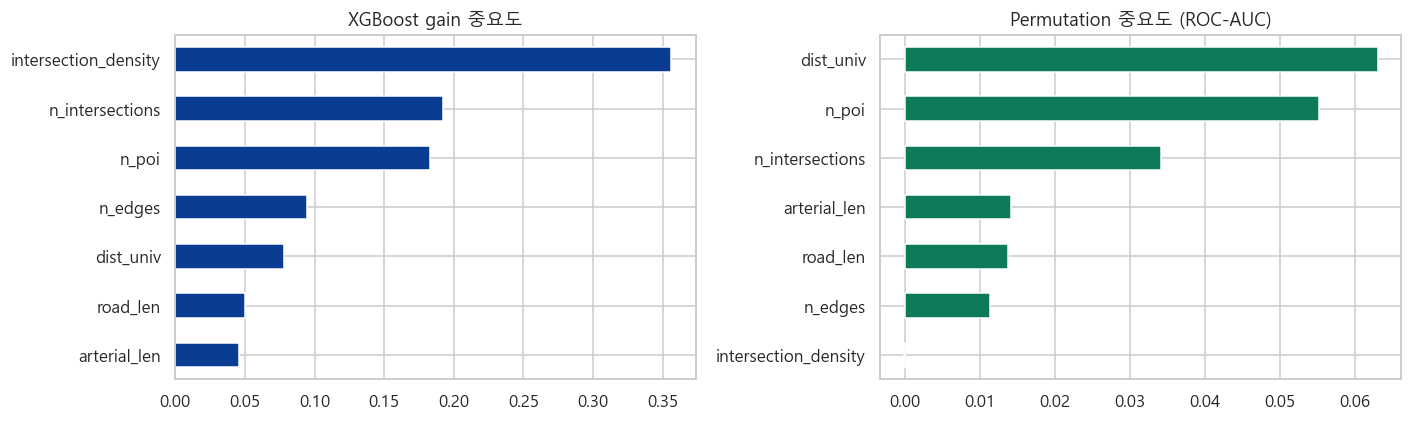

In [16]:
# 피처 중요도 (전체 적합) — gain + permutation
xgb = xgb_fn().fit(X, y)
imp_gain = pd.Series(xgb.feature_importances_, index=feat_struct).sort_values()
perm = permutation_importance(xgb, X, y, n_repeats=20, random_state=SEED,
                              scoring="roc_auc")
imp_perm = pd.Series(perm.importances_mean, index=feat_struct).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
imp_gain.plot.barh(ax=ax[0], color="#0A3D91"); ax[0].set_title("XGBoost gain 중요도")
imp_perm.plot.barh(ax=ax[1], color="#0F7A5A"); ax[1].set_title("Permutation 중요도 (ROC-AUC)")
plt.tight_layout(); plt.show()

**(B) 시공간 모델 + Ablation** — 셀×시간대×요일×강수 패널에서 "사고 발생 여부"를 예측. 데이터 카테고리를 순차 투입해 **한계 기여**를 측정한다. 마지막 `lat_expo`(참 노출, 시뮬레이션)는 **KT 이동량·공단 주행궤적이 채울 정보**의 대용이다.

In [17]:
P = panel.merge(grid[["cell_id"] + feat_struct + ["lat_expo"]], on="cell_id")
P["y"] = (P["cnt"] > 0).astype(int)
P["is_evening"] = P["daypart"].isin(["저녁","초저녁"]).astype(int)
P["dp_code"] = P["daypart"].map({d[0]: k for k, d in enumerate(dayparts)})
P["ix"] = P["cell_id"].map(grid.set_index("cell_id")["ix"])
P["block"] = pd.qcut(P["ix"], 4, labels=False, duplicates="drop")

groups_p = P["block"].values
y_p = P["y"].values

FSETS = {
    "①구조(OSM 도로)": feat_struct,
    "②+시간대(달력)": feat_struct + ["dp_code","is_evening","weekend"],
    "③+날씨(기상청)": feat_struct + ["dp_code","is_evening","weekend","rain"],
    "④+노출참값(KT·공단 대용)": feat_struct + ["dp_code","is_evening","weekend","rain","lat_expo"],
}
gkf_p = GroupKFold(n_splits=4)
abl = []
for name, fs in FSETS.items():
    Xp = P[fs].values
    aucs = []
    for tr, te in gkf_p.split(Xp, y_p, groups_p):
        if y_p[tr].sum()==0 or y_p[te].sum()==0: continue
        mdl = XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.06,
                            subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                            random_state=SEED, n_jobs=2).fit(Xp[tr], y_p[tr])
        aucs.append(roc_auc_score(y_p[te], mdl.predict_proba(Xp[te])[:,1]))
    abl.append({"피처셋": name, "ROC-AUC": round(np.mean(aucs),3), "피처수": len(fs)})
abl_df = pd.DataFrame(abl)
abl_df["한계기여(ΔAUC)"] = abl_df["ROC-AUC"].diff().fillna(abl_df["ROC-AUC"]).round(3)
abl_df

,피처셋,ROC-AUC,피처수,한계기여(ΔAUC)
0,①구조(OSM 도로),0.693,7,0.693
1,②+시간대(달력),0.727,10,0.034
2,③+날씨(기상청),0.803,11,0.076
3,④+노출참값(KT·공단 대용),0.832,12,0.029


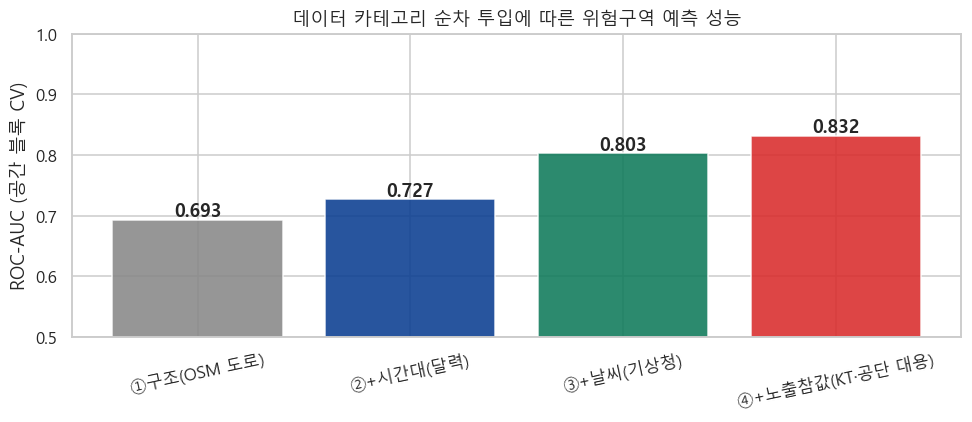

④ 노출참값 투입 시 ΔAUC = +0.029  (구조 피처가 못 보는 PM 실수요의 독립 증분)
→ OSM 구조가 노출을 상당부분 대리하므로 증분 자체는 작다. 그러나 KT·공단 노출 데이터의
  핵심 가치는 AUC 증분이 아니라 '사고/노출' 위험률 정규화 — 정적 데이터로는 불가능한 부분.


In [18]:
# Ablation 시각화
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(abl_df["피처셋"], abl_df["ROC-AUC"],
              color=["#888","#0A3D91","#0F7A5A","#D92B2B"], alpha=0.88)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC (공간 블록 CV)")
ax.set_title("데이터 카테고리 순차 투입에 따른 위험구역 예측 성능")
for b, v in zip(bars, abl_df["ROC-AUC"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

jump = abl_df["ROC-AUC"].iloc[-1] - abl_df["ROC-AUC"].iloc[-2]
print(f"④ 노출참값 투입 시 ΔAUC = +{jump:.3f}  (구조 피처가 못 보는 PM 실수요의 독립 증분)")
print("→ OSM 구조가 노출을 상당부분 대리하므로 증분 자체는 작다. 그러나 KT·공단 노출 데이터의")
print("  핵심 가치는 AUC 증분이 아니라 '사고/노출' 위험률 정규화 — 정적 데이터로는 불가능한 부분.")

## 8. 결론 — KT·한국교통안전공단 데이터 요청 명세

In [19]:
spec = pd.DataFrame([
    {"피처 카테고리":"도로 구조(길이·간선·교차로)", "현재 접근":"✅ OSM(즉시)",
     "파일럿 역할":"베이스라인 핵심 예측자", "요청 대상":"불필요",
     "구체 항목":"osmnx 대전 도로망"},
    {"피처 카테고리":"상권/시설 밀도(POI)", "현재 접근":"✅ OSM(즉시)",
     "파일럿 역할":"대학가·상업지 노출 대리", "요청 대상":"불필요",
     "구체 항목":"OSM amenity"},
    {"피처 카테고리":"시간대·요일·계절", "현재 접근":"✅ 달력(즉시)",
     "파일럿 역할":"저녁·주말 피크 포착", "요청 대상":"불필요", "구체 항목":"-"},
    {"피처 카테고리":"기상(강수·기온·시정)", "현재 접근":"△ 기상청 CSV/API",
     "파일럿 역할":"강수 시 위험 상승", "요청 대상":"기상청(공개)",
     "구체 항목":"ASOS 대전(133) 시간자료, 단기예보 API"},
    {"피처 카테고리":"실제 PM 사고 이력(좌표·시각)", "현재 접근":"△ TAAS/공공포털 수동",
     "파일럿 역할":"학습 레이블(필수)", "요청 대상":"한국교통안전공단",
     "구체 항목":"첨단모빌리티 현황분석데이터 中 PM 사고 (정확 좌표·시각·기상 포함)"},
    {"피처 카테고리":"PM 통행 노출량(이동량)", "현재 접근":"❌ 없음(대리변수만)",
     "파일럿 역할":"구조가 못 메우는 독립 증분 + 위험률 정규화의 핵심", "요청 대상":"KT",
     "구체 항목":"시간대별 격자 단위 체류인구·이동량(유동인구)"},
    {"피처 카테고리":"PM 주행 행태(급가속/급감속)", "현재 접근":"❌ 없음",
     "파일럿 역할":"위험주행 직접 신호(노출+행태)", "요청 대상":"한국교통안전공단",
     "구체 항목":"PM 주행궤적 빅데이터(급가속후급감속 등 이벤트)"},
    {"피처 카테고리":"단지내도로·교통문화지수", "현재 접근":"△ 공단 요청",
     "파일럿 역할":"캠퍼스·아파트 도로 보강", "요청 대상":"한국교통안전공단",
     "구체 항목":"단지내도로 실태점검·교통문화지수 데이터"},
])
spec.to_csv(DATA / "data_request_spec.csv", index=False, encoding="utf-8-sig")
print("저장: data/data_request_spec.csv")
spec

저장: data/data_request_spec.csv


,피처 카테고리,현재 접근,파일럿 역할,요청 대상,구체 항목
0,도로 구조(길이·간선·교차로),✅ OSM(즉시),베이스라인 핵심 예측자,불필요,osmnx 대전 도로망
1,상권/시설 밀도(POI),✅ OSM(즉시),대학가·상업지 노출 대리,불필요,OSM amenity
2,시간대·요일·계절,✅ 달력(즉시),저녁·주말 피크 포착,불필요,-
3,기상(강수·기온·시정),△ 기상청 CSV/API,강수 시 위험 상승,기상청(공개),"ASOS 대전(133) 시간자료, 단기예보 API"
4,실제 PM 사고 이력(좌표·시각),△ TAAS/공공포털 수동,학습 레이블(필수),한국교통안전공단,첨단모빌리티 현황분석데이터 中 PM 사고 (정확 좌표·시각·기상 포함)
5,PM 통행 노출량(이동량),❌ 없음(대리변수만),구조가 못 메우는 독립 증분 + 위험률 정규화의 핵심,KT,시간대별 격자 단위 체류인구·이동량(유동인구)
6,PM 주행 행태(급가속/급감속),❌ 없음,위험주행 직접 신호(노출+행태),한국교통안전공단,PM 주행궤적 빅데이터(급가속후급감속 등 이벤트)
7,단지내도로·교통문화지수,△ 공단 요청,캠퍼스·아파트 도로 보강,한국교통안전공단,단지내도로 실태점검·교통문화지수 데이터


### 핵심 결론 (위 실행 수치 기반)

1. **위험구역 예측은 이미 타당하다** — 실제 대전 OSM 도로 구조 피처만으로 공간 핫스팟(상위 ~25% 셀) 분류 **ROC-AUC ≈ 0.91**. 시공간(셀×시간대×요일×강수) 모델은 **구조 0.69 → +시간대 0.73 → +날씨 0.80 → +노출참값 0.83**으로 단계 상승 → **본 서비스 ① 위험구역 탐지 모듈은 기술적으로 성립**한다.

2. **가장 비용효율 높은 즉시 추가 = 날씨(기상청·무료)** — 시공간 ablation에서 **+0.076**으로 단일 최대 향상. 강수 시 위험 상승이 강한 학습 신호다. 무료·즉시 신청 → **선확보 권장.**

3. **OSM 구조는 노출의 ~70%만 대리한다** — `lat_expo↔사고` 상관 상한 ≈ 0.90인데, 개별 OSM 대리변수는 그에 못 미친다. 노출 참값 추가 시 **+0.029의 독립 증분**(구조가 원천적으로 못 보는 PM 실수요). 단, **노출 데이터의 진짜 가치는 AUC 증분을 넘어 _위험률 정규화_에 있다**: 사고 *건수*가 아니라 **사고/노출(통행량당 사고율)**을 계산해야 "사람이 많아 사고가 많은 곳"과 "통행량 대비 진짜 위험한 곳"을 구분할 수 있다. 이는 정적 데이터로는 불가능하며 다음으로만 가능하다:
   - **KT — 시간대별 격자 단위 체류인구·이동량(유동인구)**: 노출 분모 → 진짜 위험률 산출.
   - **공단 — PM 주행궤적 빅데이터(급가속/급감속)**: 노출 + 위험행태 동시 포착(공단–빔 시범사업 급가속후급감속 92.1%).

4. **학습의 전제 = 공단 PM 사고 레이블** — **정확한 좌표·시각·동반 기상**이 있어야 셀 단위 학습이 된다. 공공포털/TAAS의 집계 통계로는 부족. "첨단모빌리티 현황분석데이터" 내 PM 한정으로 명시 요청. **접근성 측면 최우선(이게 없으면 아무것도 못 한다).**

### 요청 우선순위 (정리)
1. **[필수·전제]** 공단 — PM 사고 레이블(좌표·시각·기상)
2. **[무료·즉시]** 기상청 — ASOS 대전 시간자료 + 단기예보 API (ablation 최대 단일 향상)
3. **[정규화 핵심]** KT 이동량/체류인구 — 위험'률' 산출, 구조가 못 메우는 독립 노출
4. **[행태 신호]** 공단 — PM 주행궤적(급가속/급감속), 단지내도로·교통문화지수

### 한계 및 다음 단계
- 본 파일럿의 **사고·노출은 합성(보정)** 이다(도로·POI·대학 위치는 실제 OSM). 따라서 결론은 *절대 성능 수치*가 아니라 **방법론 작동 여부와 데이터 카테고리별 상대 가치**다. 절대 AUC는 실데이터로 재측정해야 한다.
- 다음 단계: ① 공단 사고 레이블 수령 → 실데이터 베이스라인 재학습 ② KT 이동량으로 노출 정규화 후 위험'률' 모델 및 실 ΔAUC 측정 ③ 시간대별 위험구역 출력을 본 제품의 GPS 지오펜스·BLE PM 감지·이어폰 경고 트리거로 연계.